In [3]:
import pandas as pd

# PrimeTrade AI Assignment

## Trader Performance Analysis Based on Bitcoin Market Sentiment

**Author:** Ramani S

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Google Colab

## 1. Introduction

This project analyzes the relationship between Bitcoin market sentiment and trader performance using the Bitcoin Fear & Greed Index and Hyperliquid historical trading data. The analysis focuses on identifying trading patterns, evaluating profitability across different market sentiments, and generating insights that can support smarter trading strategies.

## 2. Objective

The objective of this project is to analyze how Bitcoin market sentiment influences trader performance. The analysis examines trading activity, profitability, trading behavior, and coin performance under different market conditions such as Fear, Greed, Extreme Fear, Extreme Greed, and Neutral sentiment. The goal is to uncover hidden patterns and provide data-driven trading recommendations.

## 3. Import Required Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")

## 4. Load the Datasets

In [6]:
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [7]:
trader_df = pd.read_csv("historical_data.csv")
sentiment_df = pd.read_csv("fear_greed_index.csv")

In [8]:
print("Trader Dataset")
display(trader_df.head())

print("\nFear & Greed Dataset")
display(sentiment_df.head())

Trader Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Fear & Greed Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


### Observation

Both datasets were successfully loaded into the notebook. The trader dataset contains detailed transaction records, while the Fear & Greed dataset contains daily Bitcoin market sentiment information.

## 5. Initial Data Exploration

In [9]:
print("Trader Dataset Shape:", trader_df.shape)
print("Sentiment Dataset Shape:", sentiment_df.shape)

Trader Dataset Shape: (211224, 16)
Sentiment Dataset Shape: (2644, 4)


### Observation

The trader dataset contains 211,224 rows and 16 columns, while the sentiment dataset contains 2,644 rows and 4 columns.

In [10]:
print("Trader Dataset Columns")
print(trader_df.columns)

print("\nSentiment Dataset Columns")
print(sentiment_df.columns)

Trader Dataset Columns
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment Dataset Columns
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [11]:
print("Trader Dataset Information")
trader_df.info()

print("\n")

print("Sentiment Dataset Information")
sentiment_df.info()

Trader Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float6

In [12]:
print("Missing Values in Trader Dataset")
print(trader_df.isnull().sum())

print("\n")

print("Missing Values in Sentiment Dataset")
print(sentiment_df.isnull().sum())

Missing Values in Trader Dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Missing Values in Sentiment Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [13]:
print("Trader Dataset Summary")
display(trader_df.describe())

print("\n")

print("Sentiment Dataset Summary")
display(sentiment_df.describe())

Trader Dataset Summary


,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12




Sentiment Dataset Summary


,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


### Observation

No missing values were found in either dataset. Most numerical columns are correctly formatted, while the timestamp columns need to be converted into datetime format before analysis.

### Observation

No missing values were found in either dataset. Most numerical columns are correctly formatted, while the timestamp columns need to be converted into datetime format before analysis.

In [14]:
trader_df["Timestamp IST"] = pd.to_datetime(
    trader_df["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])

In [15]:
print("Trader Timestamp Data Type:")
print(trader_df["Timestamp IST"].dtype)

print("\nSentiment Date Data Type:")
print(sentiment_df["date"].dtype)

Trader Timestamp Data Type:
datetime64[ns]

Sentiment Date Data Type:
datetime64[ns]


In [16]:
trader_df["date"] = trader_df["Timestamp IST"].dt.date

sentiment_df["date"] = sentiment_df["date"].dt.date

In [17]:
print("Trader Dataset")
display(trader_df[["Timestamp IST", "date"]].head())

print("\nSentiment Dataset")
display(sentiment_df[["date"]].head())

Trader Dataset


,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02



Sentiment Dataset


,date
0,2018-02-01
1,2018-02-02
2,2018-02-03
3,2018-02-04
4,2018-02-05


### Observation

The timestamp columns were successfully converted into datetime format. A common `date` column was created in both datasets to enable merging based on trading date and market sentiment date.

## 7. Merge Trader Data with Market Sentiment

In [18]:
merged_df = pd.merge(
    trader_df,
    sentiment_df,
    on="date",
    how="left"
)

In [19]:
print("Merged Dataset Shape:")
print(merged_df.shape)

display(merged_df.head())

Merged Dataset Shape:
(211224, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [20]:
display(
    merged_df[["date", "classification", "value"]].head(10)
)

,date,classification,value
0,2024-12-02,Extreme Greed,80.0
1,2024-12-02,Extreme Greed,80.0
2,2024-12-02,Extreme Greed,80.0
3,2024-12-02,Extreme Greed,80.0
4,2024-12-02,Extreme Greed,80.0
5,2024-12-02,Extreme Greed,80.0
6,2024-12-02,Extreme Greed,80.0
7,2024-12-02,Extreme Greed,80.0
8,2024-12-02,Extreme Greed,80.0
9,2024-12-02,Extreme Greed,80.0


### Observation

The datasets were successfully merged using the `date` column. Each trade now contains the corresponding Bitcoin market sentiment (Fear, Greed, Extreme Fear, Extreme Greed, or Neutral), enabling sentiment-based performance analysis.

# 8. Exploratory Data Analysis (EDA)

## 8.1 Number of Trades by Market Sentiment

In [21]:
trade_count = merged_df["classification"].value_counts()

print(trade_count)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


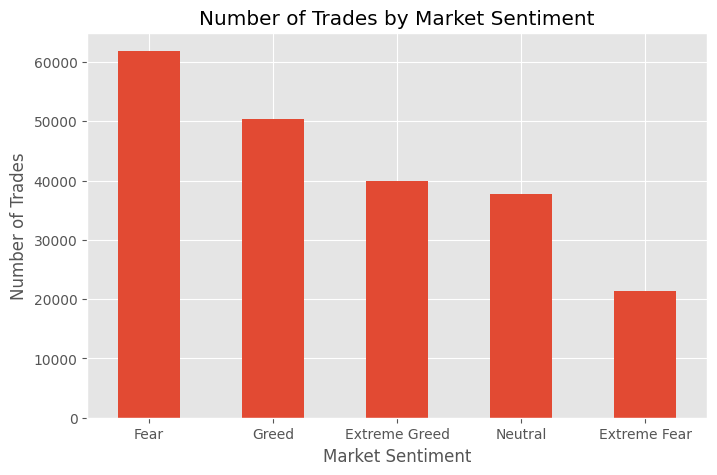

In [22]:
plt.figure(figsize=(8,5))

trade_count.plot(kind="bar")

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=0)

plt.show()

### Observation

Fear recorded the highest number of trades, followed by Greed and Extreme Greed. Extreme Fear had the lowest trading activity, indicating that traders were more active during Fear and Greed market conditions.

## 8.2 Average Closed PnL by Market Sentiment

In [23]:
avg_pnl = (
    merged_df.groupby("classification")["Closed PnL"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_pnl)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


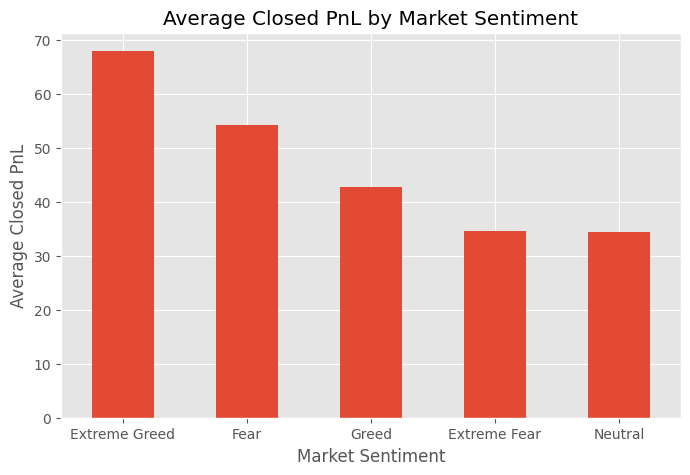

In [24]:
plt.figure(figsize=(8,5))

avg_pnl.plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=0)

plt.show()

### Observation

Extreme Greed recorded the highest average Closed PnL, followed by Fear. Neutral and Extreme Fear showed the lowest average profits, indicating that bullish market conditions generally resulted in better trader performance.

## 8.3 Total Closed PnL by Market Sentiment

In [25]:
total_pnl = (
    merged_df.groupby("classification")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
)

print(total_pnl)

classification
Fear             3.357155e+06
Extreme Greed    2.715171e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Extreme Fear     7.391102e+05
Name: Closed PnL, dtype: float64


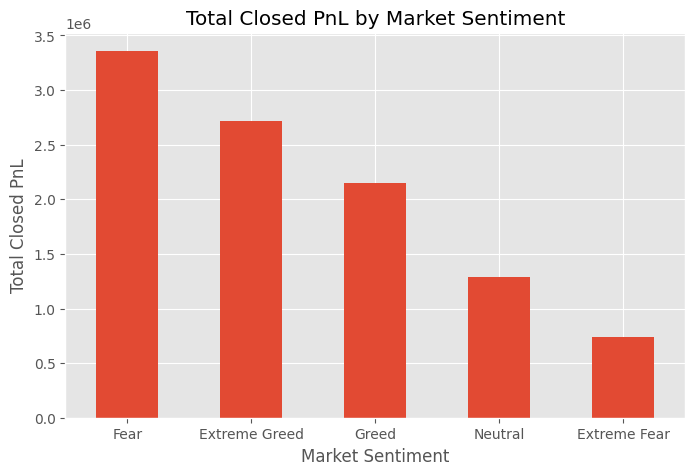

In [26]:
plt.figure(figsize=(8,5))

total_pnl.plot(kind="bar")

plt.title("Total Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=0)

plt.show()

### Observation

Fear generated the highest total Closed PnL because it had the largest number of trades. Although Extreme Greed produced the highest average profit per trade, Fear achieved greater overall profitability through higher trading activity.

## 8.4 Profit Distribution by Market Sentiment

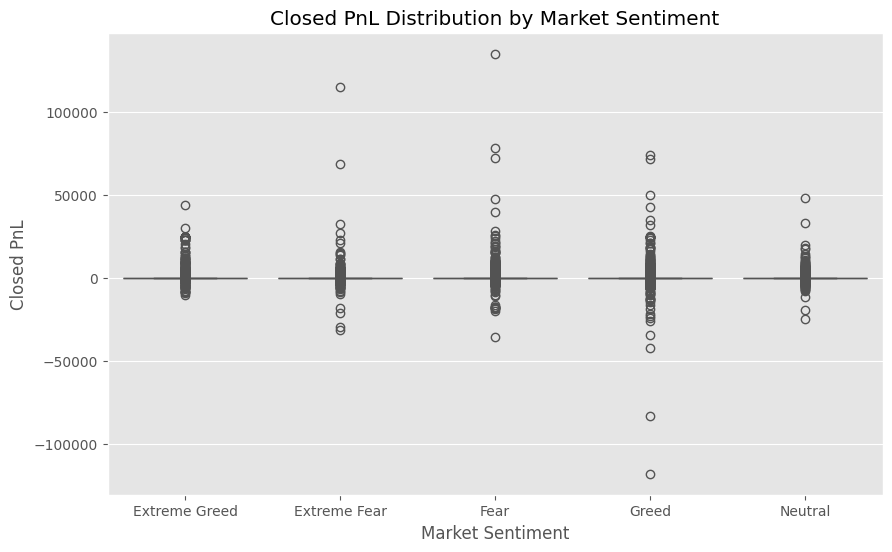

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged_df,
    x="classification",
    y="Closed PnL"
)

plt.title("Closed PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

### Observation

Most trades resulted in relatively small profits or losses across all market sentiments. However, every sentiment category contained significant outliers, indicating that a small number of trades contributed disproportionately to overall profitability.

## 8.5 Win Rate by Market Sentiment

In [28]:
merged_df["Trade Result"] = merged_df["Closed PnL"].apply(
    lambda x: "Profit" if x > 0 else "Loss"
)

trade_result = pd.crosstab(
    merged_df["classification"],
    merged_df["Trade Result"]
)

win_rate = (
    trade_result["Profit"] /
    (trade_result["Profit"] + trade_result["Loss"])
) * 100

print(win_rate.sort_values(ascending=False))

classification
Extreme Greed    46.494299
Fear             42.076750
Neutral          39.699093
Greed            38.482794
Extreme Fear     37.060748
dtype: float64


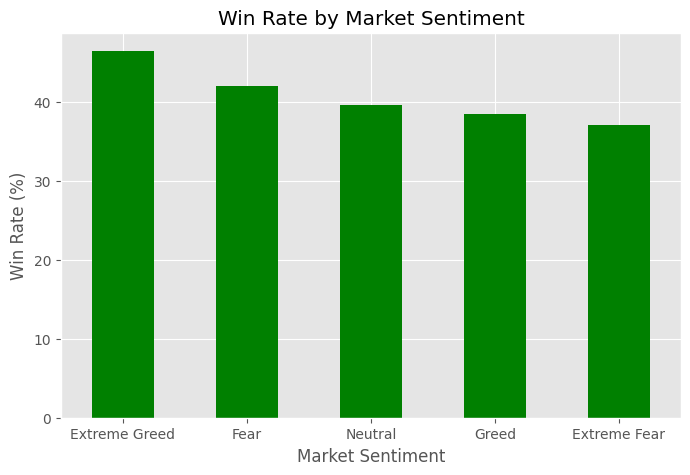

In [29]:
plt.figure(figsize=(8,5))

win_rate.sort_values(ascending=False).plot(
    kind="bar",
    color="green"
)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.xticks(rotation=0)

plt.show()

### Observation

Extreme Greed achieved the highest win rate, while Extreme Fear recorded the lowest. This suggests that bullish market conditions provided a more favorable environment for profitable trading.

## 8.6 Buy vs Sell Analysis by Market Sentiment

In [30]:
buy_sell = pd.crosstab(
    merged_df["classification"],
    merged_df["Side"]
)

print(buy_sell)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


<Figure size 800x500 with 0 Axes>

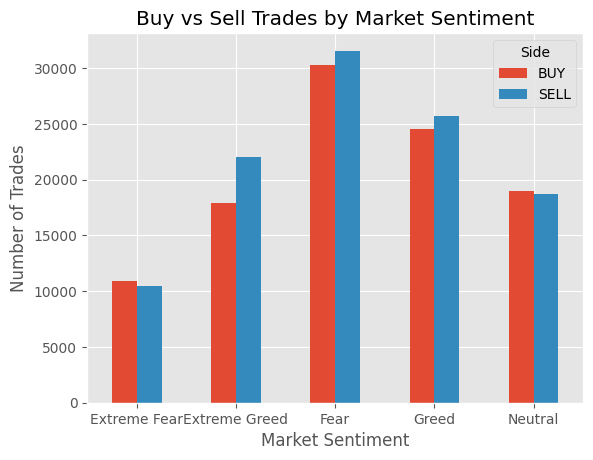

In [31]:
plt.figure(figsize=(8,5))

buy_sell.plot(kind="bar")

plt.title("Buy vs Sell Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=0)

plt.show()

### Observation

Fear recorded the highest number of both BUY and SELL trades. SELL trades slightly exceeded BUY trades across most market sentiments, while Neutral markets showed nearly equal BUY and SELL activity.

## 8.7 Average Trade Size by Market Sentiment

In [32]:
avg_trade_size = (
    merged_df.groupby("classification")["Size USD"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_trade_size)

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64


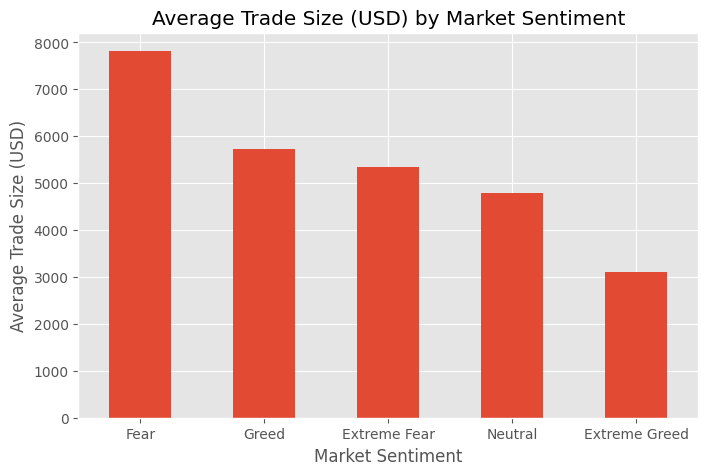

In [33]:
plt.figure(figsize=(8,5))

avg_trade_size.plot(kind="bar")

plt.title("Average Trade Size (USD) by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.xticks(rotation=0)

plt.show()

### Observation

Fear exhibited the highest average trade size, indicating that traders committed larger amounts of capital during uncertain market conditions. Extreme Greed showed the lowest average trade size.

In [ ]:
## 8.8 Top 10 Traders by Total Closed PnL

In [34]:
top_traders = (
    merged_df.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


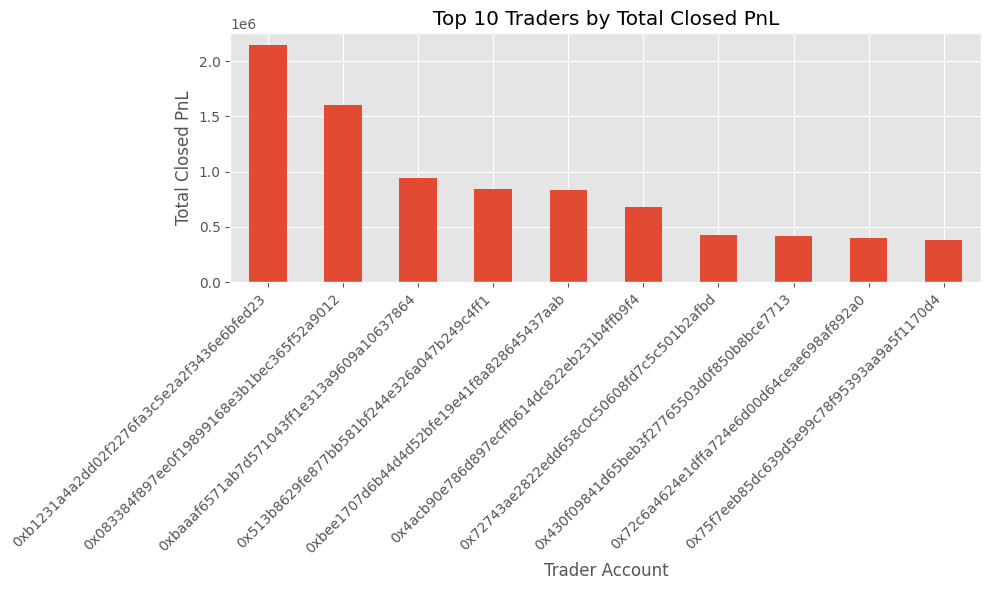

In [35]:
plt.figure(figsize=(10,6))

top_traders.plot(kind="bar")

plt.title("Top 10 Traders by Total Closed PnL")
plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Observation

A small number of traders generated a significant portion of the overall profits. The leading trader achieved over 2 million in cumulative Closed PnL, indicating that profitability was concentrated among a few high-performing accounts.

## 8.9 Top 10 Coins by Total Closed PnL

In [36]:
coin_profit = (
    merged_df.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(coin_profit)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


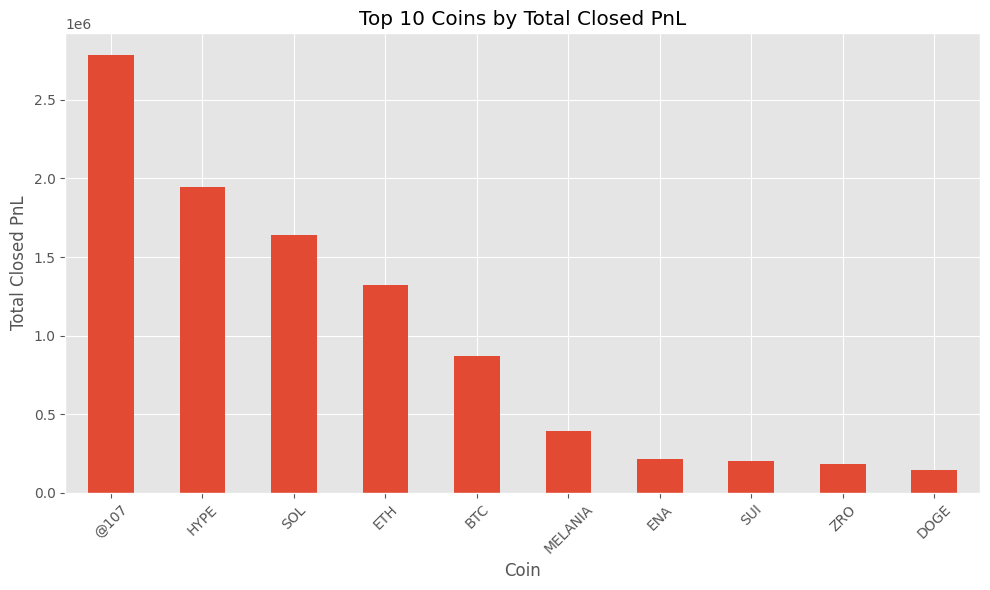

In [37]:
plt.figure(figsize=(10,6))

coin_profit.plot(kind="bar")

plt.title("Top 10 Coins by Total Closed PnL")
plt.xlabel("Coin")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observation

The highest cumulative profits were generated from @107, followed by HYPE and SOL. This indicates that profitability was concentrated in a small number of digital assets.

## 8.10 Top 10 Most Traded Coins

In [38]:
coin_trades = (
    merged_df["Coin"]
    .value_counts()
    .head(10)
)

print(coin_trades)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


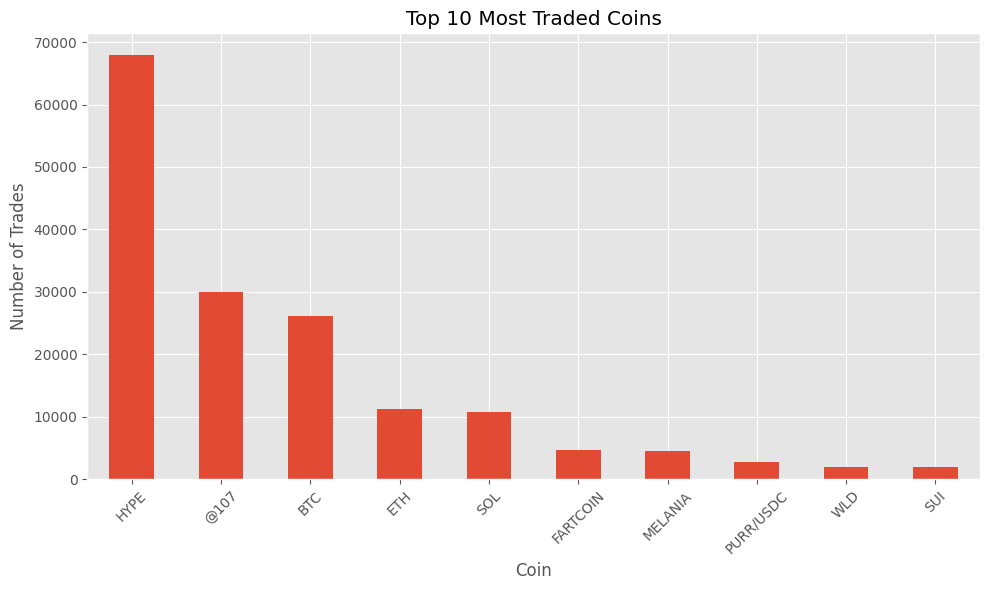

In [39]:
plt.figure(figsize=(10,6))

coin_trades.plot(kind="bar")

plt.title("Top 10 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observation

HYPE was the most actively traded cryptocurrency, followed by @107 and BTC. The most frequently traded asset was not necessarily the most profitable, highlighting the importance of evaluating multiple performance metrics.

## 8.11 Top 10 Coins by Average Closed PnL

In [40]:
avg_coin_pnl = (
    merged_df.groupby("Coin")["Closed PnL"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(avg_coin_pnl)

Coin
@109       270.704207
AVAX       239.095613
ENA        219.524751
@85        200.804091
EIGEN      197.063189
PEOPLE     180.323003
DOGE       178.623676
SOL        153.358519
MOODENG    151.096714
ZRO        148.327509
Name: Closed PnL, dtype: float64


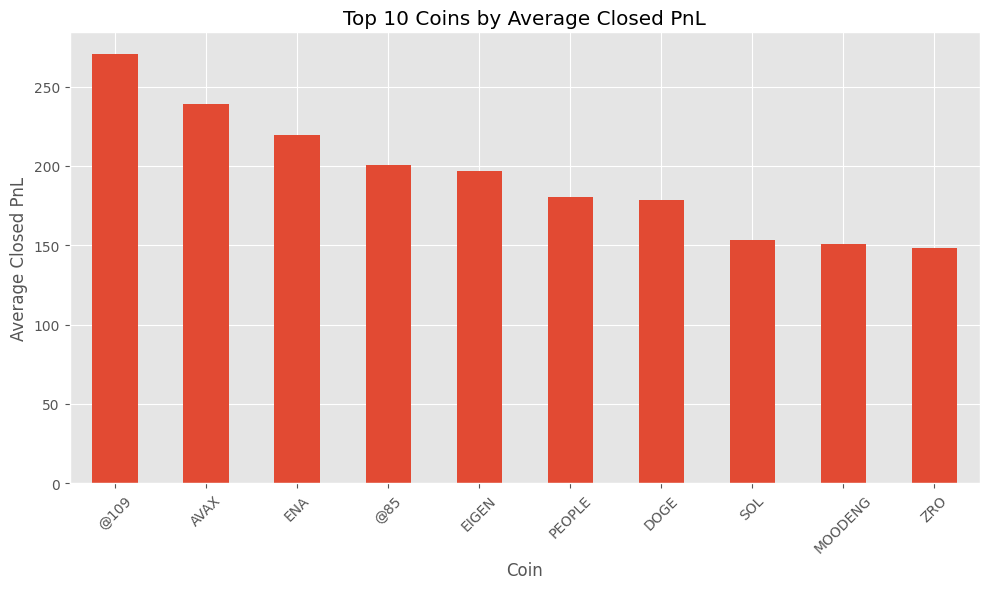

In [41]:
plt.figure(figsize=(10,6))

avg_coin_pnl.plot(kind="bar")

plt.title("Top 10 Coins by Average Closed PnL")
plt.xlabel("Coin")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observation

Different metrics identified different top-performing assets. While HYPE dominated in trading activity and @107 generated the highest cumulative profit, @109 delivered the highest average profit per trade.

## 8.12 Relationship Between Trading Fee and Profitability

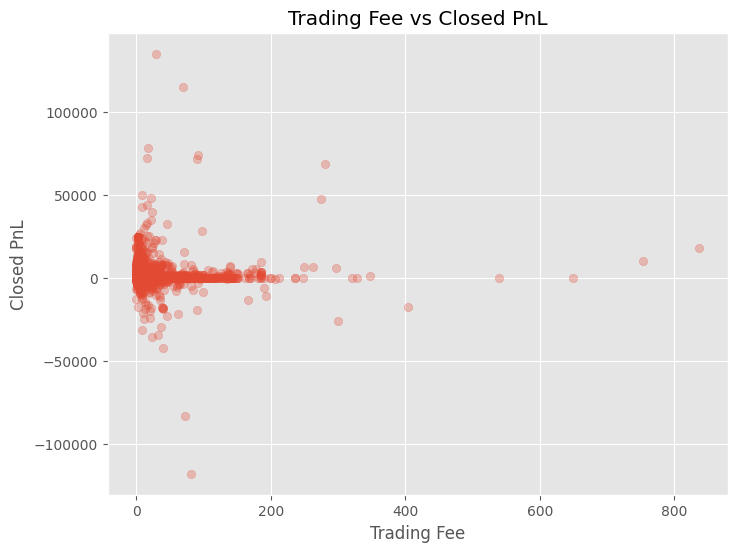

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(
    merged_df["Fee"],
    merged_df["Closed PnL"],
    alpha=0.3
)

plt.title("Trading Fee vs Closed PnL")
plt.xlabel("Trading Fee")
plt.ylabel("Closed PnL")

plt.show()

### Observation

Most trades incurred relatively low trading fees. No strong linear relationship was observed between trading fees and profitability, suggesting that paying higher fees does not necessarily lead to higher trading profits.

## 8.13 Relationship Between Trade Size and Profitability

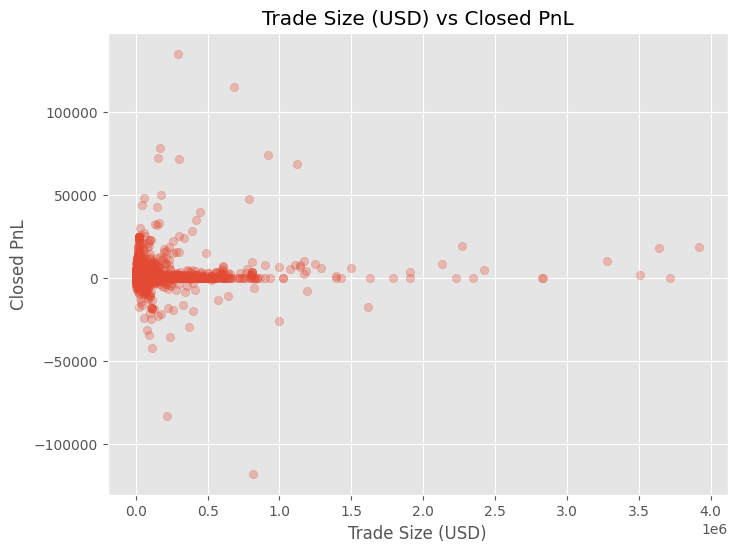

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    merged_df["Size USD"],
    merged_df["Closed PnL"],
    alpha=0.3
)

plt.title("Trade Size (USD) vs Closed PnL")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Closed PnL")

plt.show()

### Observation

Larger trade sizes resulted in both higher profits and larger losses. No strong linear relationship was observed, indicating that trade size alone is not a reliable predictor of profitability.

## 8.14 Correlation Heatmap

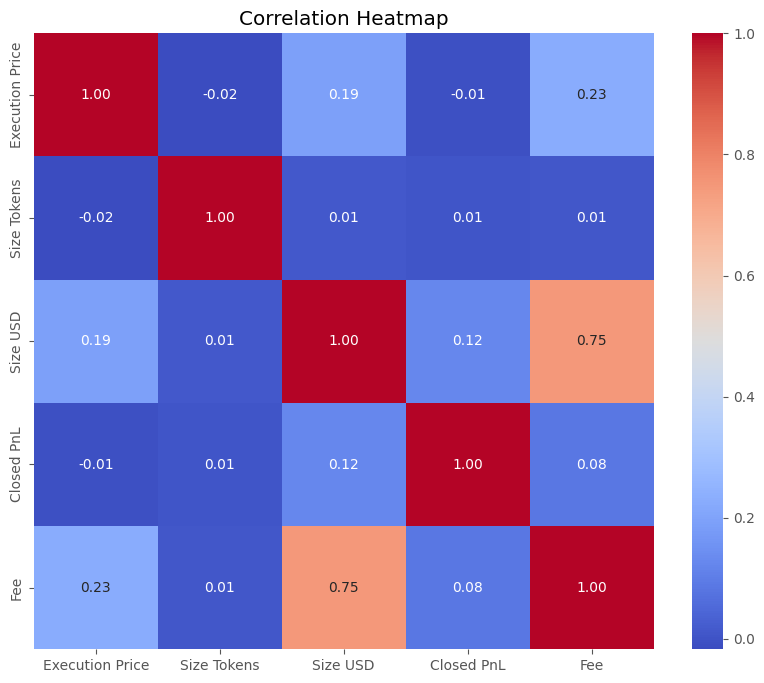

In [44]:
plt.figure(figsize=(10,8))

correlation = merged_df[
    [
        "Execution Price",
        "Size Tokens",
        "Size USD",
        "Closed PnL",
        "Fee"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The strongest positive correlation was observed between **Trade Size (USD)** and **Trading Fee**, indicating that larger trades incur higher transaction costs. Weak correlations between Closed PnL and other numerical variables suggest that trader profitability depends on multiple market factors rather than a single variable.

# 9. Key Business Insights

1. Fear recorded the highest number of trades, indicating increased trading activity during uncertain market conditions.

2. Extreme Greed achieved the highest average Closed PnL, suggesting traders earned more profit per trade during strong bullish markets.

3. Fear generated the highest total Closed PnL due to its significantly larger trading volume.

4. Extreme Greed recorded the highest win rate (46.49%), while Extreme Fear had the lowest.

5. Most trades produced relatively small profits or losses, with only a few extreme outliers contributing significantly to total profitability.

6. SELL trades slightly outnumbered BUY trades across most market sentiments.

7. Fear exhibited the highest average trade size, indicating traders committed larger amounts of capital during uncertain periods.

8. HYPE was the most actively traded cryptocurrency, whereas @107 generated the highest cumulative profit.

9. @109 produced the highest average profit per trade, demonstrating that the most profitable asset depends on the chosen evaluation metric.

10. Trade size and trading fees showed only weak relationships with profitability, suggesting that successful trading depends more on strategy and market conditions than on transaction size alone.

# 10. Trading Strategy Recommendations

1. Incorporate Bitcoin market sentiment into trading strategies, as market conditions significantly influence trader performance.

2. Apply stricter risk management during Extreme Fear periods due to the lower win rate and reduced profitability.

3. Focus on asset-specific performance instead of relying solely on trading frequency, since the most traded assets were not always the most profitable.

4. Avoid assuming that larger trade sizes or higher trading fees will result in higher profits. Position sizing should be based on risk tolerance and market analysis.

5. Continuously monitor trader performance using metrics such as average Closed PnL, win rate, and cumulative profitability to identify consistently successful trading strategies.

# 11. Conclusion

This project analyzed the relationship between Bitcoin market sentiment and trader performance using historical trading data and the Bitcoin Fear & Greed Index. The analysis revealed that market sentiment significantly influences trading behavior, profitability, and win rates. Traders achieved the highest average profitability and win rate during Extreme Greed, while Fear generated the largest overall profit due to increased trading activity. Additionally, asset selection proved to be an important factor, as the most actively traded assets were not always the most profitable. Overall, the findings demonstrate that combining market sentiment with trading analytics can support more informed decision-making and contribute to the development of smarter trading strategies.